# Data Analysis Assignment Questions

### Customer Analysis

1. Total kitne unique customers hain?
2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
3. Gender ke hisaab se total customers kitne hain?
4. Har age category ki average rating calculate karein.
5. Har gender ki average purchase value calculate karein.
6. Kis country mein sabse zyada customers hain?
7. Har country ki average review rating calculate karein.
8. Har country ka average engagement score nikaalein.
9. Kis age group ki engagement sabse zyada hai?
10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
customer_data = pd.read_excel('customers.xlsx')
product_data = pd.read_excel('products.xlsx')
engagement_data = pd.read_excel('engagement_data.xlsx')
geography_data = pd.read_excel('geography.xlsx')
customer_reviews = pd.read_excel('customer_reviews.xlsx')
customer_journey = pd.read_excel('customer_journey.xlsx')
customer_data.head()

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4


In [54]:
customer_data.shape, customer_reviews.shape, customer_journey.shape, engagement_data.shape, geography_data.shape, product_data.shape

((100, 6), (1363, 6), (4011, 7), (4623, 8), (10, 3), (20, 4))

In [55]:
# 1. Total kitne unique customers hain?
customer_data['CustomerID'].nunique()

100

In [56]:
# 2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
customer_data['Age_Category'] = pd.cut(customer_data['Age'], bins=[0, 18, 35, float('inf')], labels=['Young', 'Adult', 'Senior'])
customer_data['Age_Category'].isnull().sum()

np.int64(0)

In [57]:
# 3. Gender ke hisaab se total customers kitne hain?

customer_data['Age_Category'].value_counts()

Age_Category
Senior    63
Adult     35
Young      2
Name: count, dtype: int64

In [58]:
customer_reviews.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,77,18,2023-12-23,3,"Average experience, nothing special."
1,2,80,19,2024-12-25,5,The quality is top-notch.
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper."
4,5,64,2,2023-07-16,3,"Average experience, nothing special."


In [59]:
# 4. Har age category ki average rating calculate karein.
customer_updated_data = pd.merge(customer_data, customer_reviews, on='CustomerID', how='left')
average_rating_by_age_category = customer_updated_data.groupby('Age_Category')['Rating'].mean()
average_rating_by_age_category

Age_Category
Young     3.172414
Adult     3.710680
Senior    3.689866
Name: Rating, dtype: float64

In [60]:
customer_updated_data.isna().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
Age_Category    0
ReviewID        0
ProductID       0
ReviewDate      0
Rating          0
ReviewText      0
dtype: int64

In [61]:
# 5. Har gender ki average purchase value calculate karein.
product_data.columns.tolist(), customer_journey.columns.tolist()

(['ProductID', 'ProductName', 'Category', 'Price'],
 ['JourneyID',
  'CustomerID',
  'ProductId',
  'VisitDate',
  'Stage',
  'Action',
  'Duration'])

In [62]:
customer_journey[customer_journey['Action'] == 'Purchase']

,JourneyID,CustomerID,ProductId,VisitDate,Stage,Action,Duration
35,36,17,2,2023-11-20,Checkout,Purchase,137.0
75,76,42,17,2025-05-29,Checkout,Purchase,261.0
77,78,46,17,2025-06-15,Checkout,Purchase,122.0
80,81,89,15,2025-10-27,Checkout,Purchase,246.0
83,84,79,15,2025-03-09,Checkout,Purchase,48.0
...,...,...,...,...,...,...,...
3863,3864,65,5,2024-01-06,Checkout,Purchase,249.0
3875,3876,95,17,2025-10-30,Checkout,Purchase,231.0
3912,3913,45,9,2023-11-15,Checkout,Purchase,66.0
3951,151,79,20,2023-11-04,Checkout,Purchase,298.0


In [63]:
customer_journey = customer_journey.rename(columns={'ProductId': 'ProductID'})
customer_journey_updated = pd.merge(customer_journey, product_data, on='ProductID', how='left')
customer_journey_updated.head()

,JourneyID,CustomerID,ProductID,VisitDate,Stage,Action,Duration,ProductName,Category,Price
0,1,64,18,2024-06-10,Checkout,Drop-off,NaN,Volleyball,Sports,42.80
1,2,94,11,2025-07-09,Checkout,Drop-off,NaN,Ski Boots,Sports,340.20
2,3,34,8,2024-06-14,ProductPage,View,235.0,Football Helmet,Sports,44.75
3,4,33,18,2025-05-28,Checkout,Drop-off,NaN,Volleyball,Sports,42.80
4,5,91,10,2023-02-11,Homepage,Click,156.0,Golf Clubs,Sports,81.59


In [64]:
# 5. Har gender ki average purchase value calculate karein.
purchase_data = customer_journey_updated[customer_journey_updated['Action'].str.lower() == 'purchase']
purchase_data = purchase_data.merge(customer_data[['CustomerID', 'Gender']], on='CustomerID', how='left')
gender_average_purchase_value = purchase_data.groupby('Gender')['Price'].mean()
gender_average_purchase_value

Gender
Female    220.633273
Male      217.965000
Name: Price, dtype: float64

In [65]:
customer_journey

,JourneyID,CustomerID,ProductID,VisitDate,Stage,Action,Duration
0,1,64,18,2024-06-10,Checkout,Drop-off,NaN
1,2,94,11,2025-07-09,Checkout,Drop-off,NaN
2,3,34,8,2024-06-14,ProductPage,View,235.0
3,4,33,18,2025-05-28,Checkout,Drop-off,NaN
4,5,91,10,2023-02-11,Homepage,Click,156.0
...,...,...,...,...,...,...,...
4006,1705,54,15,2025-12-14,Homepage,View,97.0
4007,1248,17,8,2023-12-13,homepage,Click,153.0
4008,2837,75,3,2023-06-13,ProductPage,View,195.0
4009,2773,23,4,2025-08-15,ProductPage,View,79.0


In [66]:
# 6. Kis country mein sabse zyada customers hain?

geography_data_updated = pd.merge(geography_data, customer_journey, left_on='ID', right_on='CustomerID', how='left')
geography_data_updated.groupby('Region')['CustomerID'].idxmax()

Region
Austria        279
Belgium        190
France          69
Germany         35
Italy          129
Netherlands    158
Spain           97
Sweden         217
Switzerland    254
UK               0
Name: CustomerID, dtype: int64

In [67]:
## 7. Har country ki average review rating calculate karein.
geography_data_updated = pd.merge(geography_data, customer_reviews, left_on='ID', right_on='CustomerID', how='left')
geography_data_updated.groupby('Region')['Rating'].mean()   

Region
Austria        3.100000
Belgium        3.312500
France         3.764706
Germany        3.230769
Italy          3.818182
Netherlands    3.681818
Spain          3.692308
Sweden         3.583333
Switzerland    3.500000
UK             4.200000
Name: Rating, dtype: float64

In [68]:
# 8. Har country ka average engagement score nikaalein.
geography_data_updated = pd.merge(geography_data, engagement_data, left_on='ID', right_on='EngagementID', how='left')
geography_data_updated.groupby('Region')['Likes'].mean()

Region
Austria         25.0
Belgium          1.0
France          32.0
Germany        114.0
Italy          306.0
Netherlands    648.0
Spain           17.0
Sweden           1.0
Switzerland    123.0
UK             190.0
Name: Likes, dtype: float64

In [69]:
# 9. Kis age group ki engagement sabse zyada hai?
engagement_data_updated = pd.merge(customer_updated_data, engagement_data, left_on='CustomerID', right_on='EngagementID', how='left')
engagement_data_updated.groupby('Age_Category')['Likes'].max()

Age_Category
Young       7
Adult     657
Senior    840
Name: Likes, dtype: int64

0 3.654002713704206
1 3.7252396166134187


C:\Users\User\AppData\Local\Temp\ipykernel_14876\1940514300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_avg_rating.index, y=gender_avg_rating.values, palette='Set2')


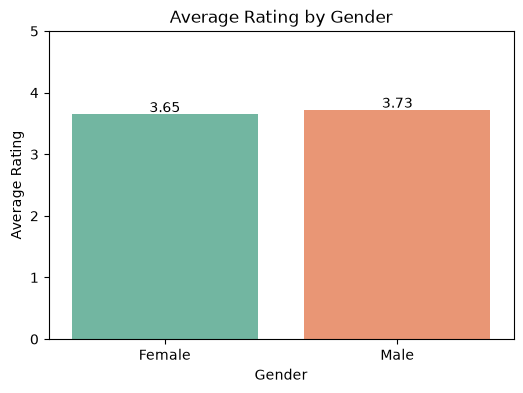

Gender
Female    3.654003
Male      3.725240
Name: Rating, dtype: float64

In [70]:
# 10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.
gender_avg_rating = customer_updated_data.groupby('Gender')['Rating'].mean().sort_values()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=gender_avg_rating.index, y=gender_avg_rating.values, palette='Set2')

for i, v in enumerate(gender_avg_rating.values):
    print(i, v)
    ax.text(i, v + 0.03, f'{v:.2f}', ha='center')

plt.title('Average Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.show()

gender_avg_rating


### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

In [71]:
# 11. Sabse zyada purchase hone wale Top 10 products dikhayein.
product_data_updated = pd.merge(customer_journey, product_data, on='ProductID', how='left')
product_purchases = product_data_updated[product_data_updated['Action'] == 'Purchase'].groupby('ProductName').size().sort_values(ascending=False).head(10)
product_purchases

ProductName
Hockey Stick       15
Baseball Glove     13
Ice Skates         13
Ski Boots          13
Surfboard          12
Cycling Helmet     12
Climbing Rope      12
Fitness Tracker    11
Yoga Mat           10
Tennis Racket      10
dtype: int64

In [72]:
# 12. Sabse zyada reviews kis products ko mile hain?
customer_reviews_updated = pd.merge(customer_reviews, product_data, on='ProductID', how='left')
customer_reviews_updated.groupby('ProductName')['ReviewID'].size().sort_values(ascending=False)


ProductName
Ice Skates         79
Fitness Tracker    76
Dumbbells          75
Kayak              75
Soccer Ball        75
Swim Goggles       73
Baseball Glove     73
Surfboard          72
Tennis Racket      72
Climbing Rope      69
Ski Boots          67
Yoga Mat           65
Football Helmet    64
Basketball         64
Golf Clubs         64
Running Shoes      63
Hockey Stick       63
Boxing Gloves      59
Volleyball         59
Cycling Helmet     56
Name: ReviewID, dtype: int64

In [73]:
engagement_data.columns.tolist(), product_data.columns.tolist()

(['EngagementID',
  'ContentID',
  'ContentType',
  'Likes',
  'EngagementDate',
  'CompaignID',
  'ProductID',
  'ViewsClickCombined'],
 ['ProductID', 'ProductName', 'Category', 'Price'])

In [74]:
# 13. Sabse zyada engagement wale Top 10 products identify karein.
engagement_data_updated = pd.merge(engagement_data, product_data, on='ProductID', how='left')
engagement_data_updated.groupby('ProductName')['Likes'].sum().sort_values(ascending=False).head(10)

ProductName
Running Shoes     31106
Soccer Ball       30009
Yoga Mat          29590
Basketball        29583
Swim Goggles      29382
Golf Clubs        28716
Kayak             28213
Hockey Stick      27862
Baseball Glove    27452
Ice Skates        27339
Name: Likes, dtype: int64

In [75]:
# 14. Har product category ki average rating calculate karein.
customer_reviews_updated.groupby('Category')['Rating'].mean()

Category
Sports    3.68672
Name: Rating, dtype: float64

In [76]:
# 15. Har category ki average engagement calculate karein.
engagement_data_updated[['View', 'Clicks']] = engagement_data_updated['ViewsClickCombined'].str.split('-', expand=True)
engagement_data_updated['View'] = pd.to_numeric(engagement_data_updated['View'], errors='coerce')
engagement_data_updated['Clicks'] = pd.to_numeric(engagement_data_updated['Clicks'], errors='coerce')
engagement_data_updated.groupby('Category')[['Likes', 'View', 'Clicks']].mean()

,Likes,View,Clicks
Category,,,
Sports,114.368592,2545.892664,498.152132


In [77]:
# 16. Har category ki average views aur clicks compare karein.

engagement_data_updated.groupby('Category')[['View', 'Clicks']].mean()

,View,Clicks
Category,,
Sports,2545.892664,498.152132


In [78]:
# 17. Lowest rated Top 10 products kaun se hain?
customer_reviews_updated.groupby('ProductName')['Rating'].mean().sort_values(ascending=True).head(10)

ProductName
Golf Clubs       3.484375
Yoga Mat         3.523077
Tennis Racket    3.555556
Running Shoes    3.571429
Volleyball       3.576271
Boxing Gloves    3.610169
Dumbbells        3.626667
Surfboard        3.652778
Soccer Ball      3.666667
Hockey Stick     3.666667
Name: Rating, dtype: float64

In [79]:
## 18. Highest rated Top 10 products kaun se hain?
customer_reviews_updated.groupby('ProductName')['Rating'].mean().sort_values(ascending=False).head(10)

ProductName
Climbing Rope      3.913043
Swim Goggles       3.835616
Cycling Helmet     3.803571
Kayak              3.786667
Basketball         3.781250
Fitness Tracker    3.776316
Ski Boots          3.731343
Baseball Glove     3.726027
Football Helmet    3.703125
Ice Skates         3.696203
Name: Rating, dtype: float64

In [80]:
# 19. Kis category mein views zyada hain lekin purchases kam hain?
product_data_updated['Category'].unique()

<ArrowStringArray>
['Sports']
Length: 1, dtype: str

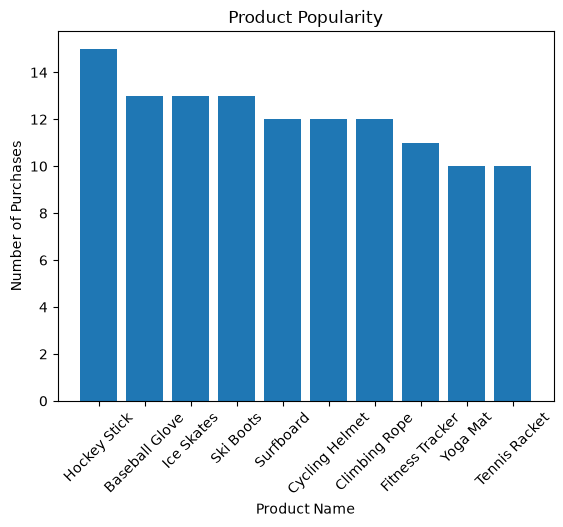

In [81]:
# 20. Product popularity ko bar chart ke zariye visualize karein.
plt.bar(product_purchases.index, product_purchases.values)
plt.xlabel('Product Name')
plt.ylabel('Number of Purchases')
plt.title('Product Popularity')
plt.xticks(rotation=45)
plt.show()

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.

In [82]:
engagement_data_updated

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined,ProductName,Category,Price,View,Clicks
0,1,39,Blog,190,2023-08-30,1,9,1883-671,Baseball Glove,Sports,327.36,1883.0,671.0
1,2,48,Blog,114,2023-03-28,18,20,5280-532,Boxing Gloves,Sports,262.32,5280.0,532.0
2,3,16,video,32,2023-12-08,7,14,1905-204,Cycling Helmet,Sports,472.32,1905.0,204.0
3,4,43,Video,17,2025-01-21,19,20,2766-257,Boxing Gloves,Sports,262.32,2766.0,257.0
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524,Climbing Rope,Sports,410.17,5116.0,1524.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4618,4619,31,Video,270,2023-05-21,3,19,8115-1872,Hockey Stick,Sports,173.83,8115.0,1872.0
4619,4620,46,newsletter,209,2023-07-17,8,4,1273-516,Dumbbells,Sports,26.21,1273.0,516.0
4620,4621,10,video,78,2023-05-24,20,7,1609-599,Basketball,Sports,225.12,1609.0,599.0
4621,4622,6,socialmedia,50,2024-04-14,18,2,3052-374,Fitness Tracker,Sports,196.68,3052.0,374.0


In [83]:
# 21. Total Views, Total Clicks aur Total Likes calculate karein.
engagement_data_updated[['View', 'Clicks', 'Likes']].sum().astype(int)

View      11764570
Clicks     2301961
Likes       528726
dtype: int64

In [84]:
# 22. Overall Engagement Rate calculate karein.
total_likes = engagement_data_updated['Likes'].sum()
total_views = engagement_data_updated['View'].sum()
total_clicks = engagement_data_updated['Clicks'].sum()
engagement_data_updated['Overall_Engagement_Rate'] = (total_clicks + total_likes) / total_views
engagement_data_updated['Overall_Engagement_Rate']

0       0.240611
1       0.240611
2       0.240611
3       0.240611
4       0.240611
          ...   
4618    0.240611
4619    0.240611
4620    0.240611
4621    0.240611
4622    0.240611
Name: Overall_Engagement_Rate, Length: 4623, dtype: float64

In [85]:
# 23. Har product ka Engagement Rate compare karein.
product_engagement = engagement_data_updated.groupby('ProductName').agg({
    'Likes': 'sum',
    'Clicks': 'sum',
    'View': 'sum'
})

product_engagement['Engagement_Rate'] = (product_engagement['Likes'] + product_engagement['Clicks']) / product_engagement['View'] * 100

product_engagement.sort_values('Engagement_Rate', ascending=False)

,Likes,Clicks,View,Engagement_Rate
ProductName,,,,
Surfboard,24622,104928.0,498753.0,25.974781
Running Shoes,31106,139019.0,660923.0,25.740517
Yoga Mat,29590,118852.0,578549.0,25.657637
Soccer Ball,30009,127671.0,623257.0,25.299355
Hockey Stick,27862,116785.0,578316.0,25.011758
Baseball Glove,27452,113642.0,565109.0,24.967573
Football Helmet,23367,107613.0,529241.0,24.748649
Kayak,28213,117854.0,592054.0,24.671229
Boxing Gloves,26512,114522.0,571937.0,24.659010


In [86]:
# 24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
engagement_data_updated.groupby('ProductName')[['View', 'Clicks']].sum().sort_values(by=['View', 'Clicks'], ascending=False).head(10)

,View,Clicks
ProductName,,
Basketball,676568.0,127290.0
Running Shoes,660923.0,139019.0
Climbing Rope,643901.0,129554.0
Ice Skates,639254.0,126104.0
Swim Goggles,637380.0,125861.0
Soccer Ball,623257.0,127671.0
Golf Clubs,617481.0,119239.0
Tennis Racket,617016.0,107464.0
Kayak,592054.0,117854.0


In [87]:
# 25. Least engaged products kaun se hain?
engagement_data_updated.groupby('ProductName')[['View', 'Clicks', 'Likes']].sum().sort_values(by=['View', 'Clicks', 'Likes'], ascending=True).head(10)

,View,Clicks,Likes
ProductName,,,
Surfboard,498753.0,104928.0,24622
Fitness Tracker,505085.0,87073.0,17205
Football Helmet,529241.0,107613.0,23367
Ski Boots,541893.0,100651.0,23915
Cycling Helmet,542610.0,99694.0,23685
Baseball Glove,565109.0,113642.0,27452
Dumbbells,567244.0,110629.0,25002
Boxing Gloves,571937.0,114522.0,26512
Volleyball,577999.0,107516.0,24961


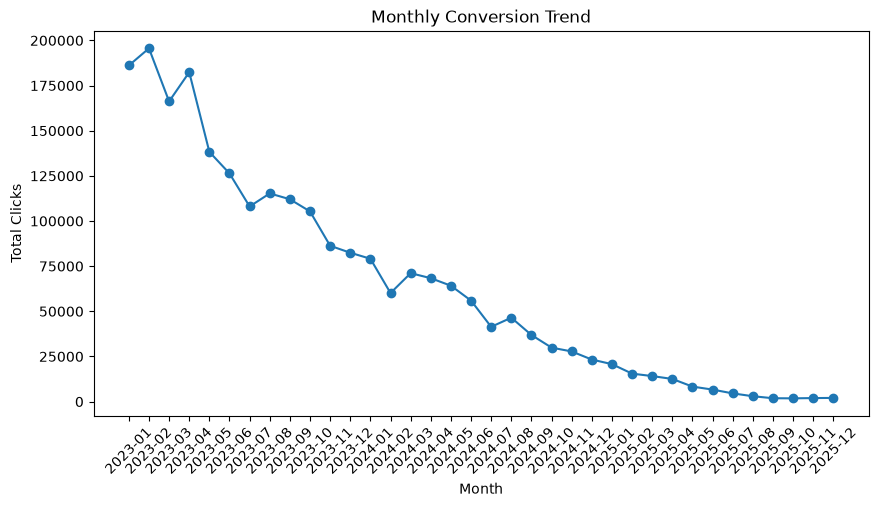

In [88]:
# 26. Daily ya Monthly conversion trend visualize karein.
engagement_data_updated['EngagementDate'] = pd.to_datetime(engagement_data_updated['EngagementDate'])

monthly_trend = engagement_data_updated.groupby(engagement_data_updated['EngagementDate'].dt.to_period('M'))['Clicks'].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend.index.astype(str), monthly_trend.values, marker='o', label='Clicks')
plt.xticks(rotation=45)
plt.title('Monthly Conversion Trend')
plt.xlabel('Month')
plt.ylabel('Total Clicks')
plt.show()

In [89]:
engagement_data_updated

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined,ProductName,Category,Price,View,Clicks,Overall_Engagement_Rate
0,1,39,Blog,190,2023-08-30,1,9,1883-671,Baseball Glove,Sports,327.36,1883.0,671.0,0.240611
1,2,48,Blog,114,2023-03-28,18,20,5280-532,Boxing Gloves,Sports,262.32,5280.0,532.0,0.240611
2,3,16,video,32,2023-12-08,7,14,1905-204,Cycling Helmet,Sports,472.32,1905.0,204.0,0.240611
3,4,43,Video,17,2025-01-21,19,20,2766-257,Boxing Gloves,Sports,262.32,2766.0,257.0,0.240611
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524,Climbing Rope,Sports,410.17,5116.0,1524.0,0.240611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4618,4619,31,Video,270,2023-05-21,3,19,8115-1872,Hockey Stick,Sports,173.83,8115.0,1872.0,0.240611
4619,4620,46,newsletter,209,2023-07-17,8,4,1273-516,Dumbbells,Sports,26.21,1273.0,516.0,0.240611
4620,4621,10,video,78,2023-05-24,20,7,1609-599,Basketball,Sports,225.12,1609.0,599.0,0.240611
4621,4622,6,socialmedia,50,2024-04-14,18,2,3052-374,Fitness Tracker,Sports,196.68,3052.0,374.0,0.240611


In [115]:
# 27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
engagement_data_updated = engagement_data_updated.rename(columns={'CompaignID': 'CampaignID'})
campaign_ctr = engagement_data_updated.groupby('CampaignID').agg({'Clicks': 'sum', 'View': 'sum'})
campaign_ctr['CTR'] = (campaign_ctr['Clicks'] / campaign_ctr['View']) * 100

campaign_ctr.sort_values('CTR', ascending=False)
engagement_data_updated = engagement_data_updated.merge(campaign_ctr[['CTR']], on='CampaignID', how='left')
engagement_data_updated

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CampaignID,ProductID,ViewsClickCombined,ProductName,Category,Price,View,Clicks,Overall_Engagement_Rate,CTR
0,1,39,Blog,190,2023-08-30,1,9,1883-671,Baseball Glove,Sports,327.36,1883.0,671.0,0.240611,17.263579
1,2,48,Blog,114,2023-03-28,18,20,5280-532,Boxing Gloves,Sports,262.32,5280.0,532.0,0.240611,21.106271
2,3,16,video,32,2023-12-08,7,14,1905-204,Cycling Helmet,Sports,472.32,1905.0,204.0,0.240611,19.319057
3,4,43,Video,17,2025-01-21,19,20,2766-257,Boxing Gloves,Sports,262.32,2766.0,257.0,0.240611,18.580621
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524,Climbing Rope,Sports,410.17,5116.0,1524.0,0.240611,19.495693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4618,4619,31,Video,270,2023-05-21,3,19,8115-1872,Hockey Stick,Sports,173.83,8115.0,1872.0,0.240611,19.575588
4619,4620,46,newsletter,209,2023-07-17,8,4,1273-516,Dumbbells,Sports,26.21,1273.0,516.0,0.240611,19.694007
4620,4621,10,video,78,2023-05-24,20,7,1609-599,Basketball,Sports,225.12,1609.0,599.0,0.240611,20.359134
4621,4622,6,socialmedia,50,2024-04-14,18,2,3052-374,Fitness Tracker,Sports,196.68,3052.0,374.0,0.240611,21.106271


In [119]:
# 28. Top performing aur lowest performing campaigns identify karein.
top_campaigns = campaign_ctr.nlargest(5, 'CTR')
lowest_campaigns = campaign_ctr.nsmallest(5, 'CTR')

top_campaigns, lowest_campaigns

(              Clicks      View        CTR
 CampaignID                               
 16          123208.0  574623.0  21.441536
 18          119826.0  567727.0  21.106271
 4           114733.0  552310.0  20.773298
 13          139068.0  670027.0  20.755581
 20          121701.0  597771.0  20.359134,
               Clicks      View        CTR
 CampaignID                               
 1            85757.0  496751.0  17.263579
 12           97224.0  563147.0  17.264409
 19          125173.0  673675.0  18.580621
 11          107302.0  575805.0  18.635128
 17          118637.0  627317.0  18.911810)

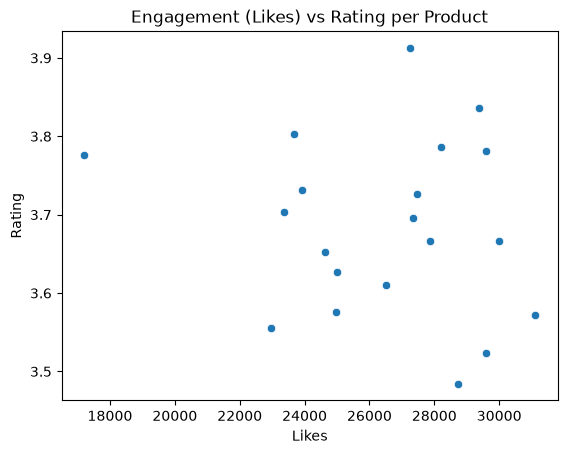

,Rating,Likes
Rating,1.000000,-0.146415
Likes,-0.146415,1.000000


In [120]:
# 29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.


# Step 1: average rating per product
rating_per_product = customer_reviews_updated.groupby('ProductName')['Rating'].mean()

# Step 2: total likes per product
likes_per_product = engagement_data_updated.groupby('ProductName')['Likes'].sum()

# Step 3: combine into one dataframe
engagement_rating_df = pd.concat([rating_per_product, likes_per_product], axis=1)
engagement_rating_df.columns = ['Rating', 'Likes']
engagement_rating_df

# Step 4: scatter plot
sns.scatterplot(x='Likes', y='Rating', data=engagement_rating_df)
plt.title('Engagement (Likes) vs Rating per Product')
plt.show()

# Step 5: correlation
engagement_rating_df.corr()

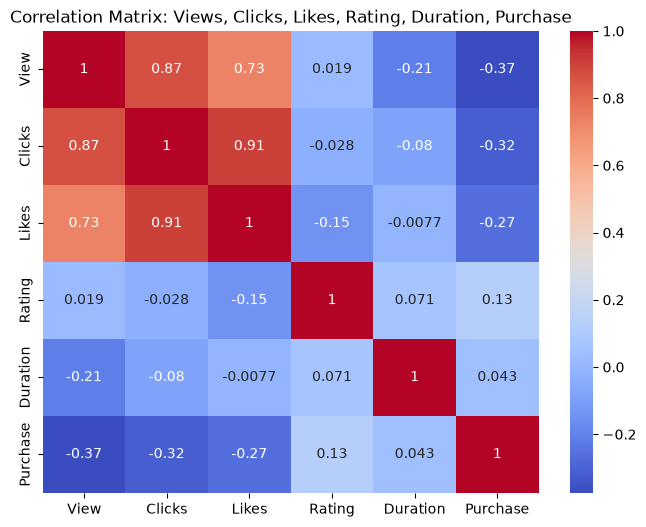

In [122]:
# 30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.

# Views, Clicks, Likes per product
engagement_per_product = engagement_data_updated.groupby('ProductName').agg({
    'View': 'sum',
    'Clicks': 'sum',
    'Likes': 'sum'
})

# Rating per product
rating_per_product = customer_reviews_updated.groupby('ProductName')['Rating'].mean()

# Duration per product (from customer_journey merged with products)
journey_updated = pd.merge(customer_journey, product_data, on='ProductID', how='left')
duration_per_product = journey_updated.groupby('ProductName')['Duration'].mean()

# Purchase count per product
purchase_per_product = journey_updated[journey_updated['Action'] == 'Purchase'].groupby('ProductName').size()
purchase_per_product.name = 'Purchase'

# Combine everything into one dataframe
combined_df = pd.concat([engagement_per_product, rating_per_product, duration_per_product, purchase_per_product], axis=1)
combined_df

# Correlation matrix
correlation_matrix = combined_df.corr()
correlation_matrix

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Views, Clicks, Likes, Rating, Duration, Purchase')
plt.show()